<a href="https://colab.research.google.com/github/jaearao/App-155/blob/Assignments/Arao_lab_assignment_module6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AP155 Lab Assignment**
## Module 6: Random Process and Monte Carlo Methods

_Instructions_: Answer each problem as completely as you can. Discuss **all** your answers as clearly and concisely as possible.

_Scoring Criteria_: 50% - *correctness of code*; 50% - *discussion of the code and results*. Maximum score is **100 points**.


### Student Information

_Full Name (Last Name, First Name)_: John Robert B. Arao\
_Student No._: 2022-01967\
_Section_: TX-3

### Submission Information

_Date and Time Submitted (most recent upload)_: 11/30/2024 9:30 pm

**HONOR PLEDGE** I affirm that I have upheld the highest principles of honesty and integrity in my academic work and that this lab assignment is my own work.

**Sign here with your full name: John Robert Arao**

### Grading Information (c/o Lab Instructor)

TOTAL SCORE: **[]**/100

Score breakdown:
* Problem 1 - []/100

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_

### PROBLEM 1

**The Ising model**

_Refer to Exercise 10.9 in the Newman text._ The Ising model is a theoretical model of a magnet. The magnetic potential energy due to the interaction of two dipoles is proportional to their dot product, but in the Ising model this simplifies to just the product $s_i s_j$ for spins on sites $i$ and $j$ of the lattice, since the spins are one-dimensional scalars, not vectors. Then the actual energy of interaction is $-Js_i s_j$, where $J$ is a positive interaction constant. The minus sign ensures that the in- teractions are ferromagnetic, meaning the energy is lower when dipoles are lined up. A ferromagnetic interaction implies that the material will magnetize if given the chance.

Normally it is assumed that spins interact only with those that are immediately adjacent to them on the lattice, which gives a total energy for the entire system equal to
$$ E = -J \sum_{\langle ij \rangle} s_i s_j,$$
where the notation $\langle ij \rangle$ indicates a sum over pairs $i,j$ that are adjacent on the lattice. On the square lattice we use in this exercise each spin has four adjacent neighbors with which it interacts, except for the spins at the edges of the lattice, which have either two or three neighbors.

Perform a Markov chain Monte Carlo simulation of the Ising model on the square lattice for a system of 20 x 20 spins. You will need to set up variables to hold the value ±1 of the spin on each lattice site, probably using a two-dimensional integer array, and then take the following steps.

1. Write a function to calculate the total energy of the system, as given by the equation above. That is, for a given array of values of the spins, go through every pair of adjacent spins and add up the contributions $s_i s_j$ from all of them, then multiply by $-J$. Hint 1: Each unique pair of adjacent spins crops up only once in the sum. Thus there is a term $-Js_1s_2$ if spins 1 and 2 are adjacent to one another, but you do not also need a term $-Js_2s_1$. Hint 2: To make your final program to run in a reasonable amount of time, you will find it helpful if you can work out a way to calculate the energy using Python's ability to do arithmetic with entire arrays at once. If you do the calculation step by step, your program will be significantly slower. *(25 pts.)*

2. Now use your function as the basis for a Metropolis-style simulation of the Ising model with $J = 1$ and temperature $T = 1$ in units where the Boltzmann constant $k_B$ is also 1. Initially set the spin variables randomly to ±1, so that on average about a half of them are up and a half down, giving a total magneti- zation of roughly zero. Then choose a spin at random, flip it, and calculate the new energy after it is flipped, and hence also the change in energy as a result of the flip. Then decide whether to accept the flip using the Metropolis acceptance formula, Eq. (10.60). If the move is rejected you will have to flip the spin back to where it was. Otherwise you keep the flipped spip. Now repeat this process for many moves. *(25 pts.)*

3. Make a plot of the total magnetization $M = \sum_i s_i$ of the system as a function of time for a million Monte Carlo steps. You should see that the system develops a "spontaneous magnetization," a nonzero value of the overall magnetization. Hint: While you are working on your program, do shorter runs, of maybe ten thousand steps at a time. Once you have it working properly, do a longer run of a million steps to get the final results. *(25 pts.)*

4. Run your program several times and observe the sign of the magnetization that develops, positive or negative. Describe what you find and give a brief explana- tion of what is happening. *(25 pts.)*

In [ ]:
import numpy as np
lat = np.zeros([20,20], dtype=int)
print(lat)

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


In [ ]:
#Define E based on the given equation
def E(lattice):
  J = 1
  energy = 0
  for i in range(len(lattice)):
    for j in range(len(lattice[0])):
      if i == len(lattice) - 1:
        energy += -J*lattice[i][j] * lattice[0][j]
      elif j == len(lattice[0]) - 1:
        energy += -J*lattice[i][j] * lattice[i][0]
      else:
        energy += -J*lattice[i][j] * (lattice[i][j + 1] + lattice[i + 1][j])
  return energy



In [ ]:
#Input the given values
T = 1
k_B = 1
beta = (1/k_B*T)

#define a function that will solve the magnetism given a seed N to run trials
def magnetism(N):
  np.random.seed(N)
  #define a function that would decide the spins where magnetism should be initially zero
  def init(lat):
    mag = np.sum(lat)
    if mag !=0:
      lat = np.random.choice([-1, 1], size=(20, 20))
      return init(lat)
    else:
      return lat

  #run the function in a randomly made array of spins
  lattice = np.random.choice([-1, 1], size=(20, 20))
  lat = init(lattice)

  #Compute the initial energy
  current_energy = E(lat)
  magnetization = []          #make an bin for the magnetization per iteration

  #run the MCMC simulation for 1 million steps
  for i in range(1000000):
    #randomly pic a spin
    x = np.random.randint(0, 20)
    y = np.random.randint(0, 20)


    #flip the spin
    lat[x][y] *= -1

    #compute the new energy
    new_energy = E(lat)

    #perform the Accept-Reject Rule
    if new_energy < current_energy: #Acceptance probability = 1 if it has a lower energy
      current_energy = new_energy
    else:                           # Use the given acceptance probability if it has higher energy
      delta_E = new_energy - current_energy
      if np.random.rand() < np.exp(-beta*delta_E):
        current_energy = new_energy
      else:                         #if rejected, flip the random spin again to its original spin
       lat[x][y] *= -1

    mag = np.sum(lat)               #compute the new magnetization
    magnetization.append(mag)

  return magnetization

In [ ]:
#decide the seeds that will be used in trials
seed = np.random.choice(1000, 3)

#run the trials
trial1 = magnetism(seed[0])
trial2 = magnetism(seed[1])
trial3 = magnetism(seed[2])

#Print the seeds for reference
print(seed)

[665 264 647]


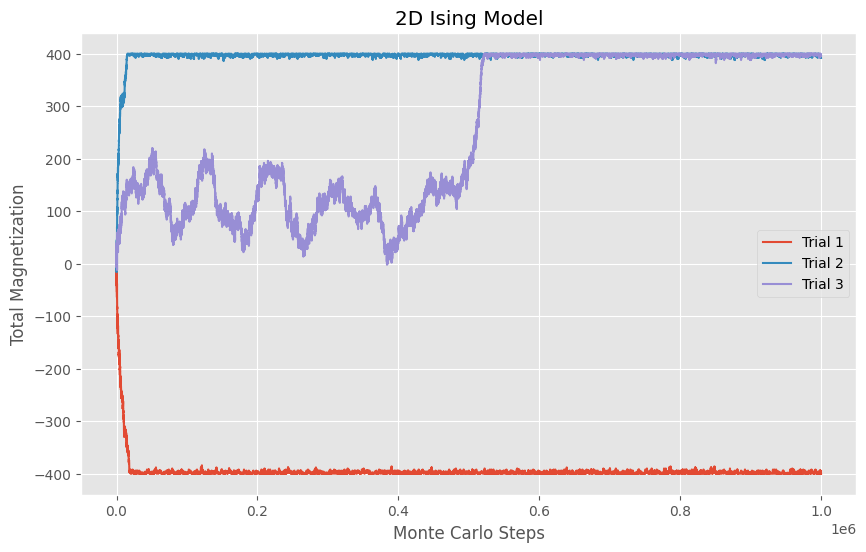

In [ ]:
import matplotlib.pyplot as plt

#Plot the results of the figures
plt.style.use('ggplot')
plt.figure(figsize=(10, 6))
plt.plot(trial1, label='Trial 1')
plt.plot(trial2, label='Trial 2')
plt.plot(trial3, label='Trial 3')
plt.xlabel('Monte Carlo Steps')
plt.ylabel('Total Magnetization')
plt.title('2D Ising Model')
plt.legend()
plt.grid(True)
plt.show()

## Discussion

The **Monte Carlo (MC)** Method gets all its power from the random samples to visualize the solution and hopes that it converges. The **Markov Chain** added to the MC Method adds more clarity to what should the solution is by integrating an acceptance probability. Together, the **Markov Chain Monte Carlo (MCMC)** Method considers the every move of the system subjected to its inherent probability.

The results above show that the 2D ising model converges to either 400 or -400. This means all the spins will eventually go up or down and the magnetization will reach its maximum value. *More trial must be done to simulate the probability of all up spins or all down spins.*

> The MCMC successfully modeled the total Magnetization of the Ising Model by randomly selecting a spin and reversing it. It shows that the Ising Model will eventually converge into a single spin system.